In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error,r2_score

In [3]:
#Loading housing data from csv file (csv-> dataframe)
df=pd.read_csv('mumbai_housing_data.csv')
print("first 5 lines of the data")
df.head()

first 5 lines of the data


,Locality,Area_sqft,BHK,Age_yrs,Floor,Total_Floors,Dist_Rail_km,Sea_View,Parking,Price_INR
0,Dadar,583.22,1,10,8,15,2.74,0,1,18045592.0
1,Bandra,784.96,1,20,4,5,4.93,0,0,23882179.0
2,Ghatkopar,793.64,3,14,19,19,3.12,1,1,24259453.0
3,Thane,968.72,1,24,18,18,3.14,0,0,18824996.0
4,Andheri,1089.77,4,34,17,18,2.14,0,1,26278509.0


In [4]:
print("\nBasic Info")
df.info()


Basic Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Locality      1000 non-null   object 
 1   Area_sqft     1000 non-null   float64
 2   BHK           1000 non-null   int64  
 3   Age_yrs       1000 non-null   int64  
 4   Floor         1000 non-null   int64  
 5   Total_Floors  1000 non-null   int64  
 6   Dist_Rail_km  1000 non-null   float64
 7   Sea_View      1000 non-null   int64  
 8   Parking       1000 non-null   int64  
 9   Price_INR     1000 non-null   float64
dtypes: float64(3), int64(6), object(1)
memory usage: 78.2+ KB


In [5]:
print("\nSummary statistic\n")
df.describe()


Summary statistic



,Area_sqft,BHK,Age_yrs,Floor,Total_Floors,Dist_Rail_km,Sea_View,Parking,Price_INR
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1.000000e+03
mean,918.867930,2.344000,19.645000,9.192000,17.026000,4.102520,0.137000,0.691000,1.932822e+07
std,251.998774,0.796428,11.363895,6.515796,7.027995,2.287982,0.344019,0.462312,6.636654e+06
min,350.000000,1.000000,0.000000,1.000000,5.000000,0.100000,0.000000,0.000000,6.065868e+06
25%,737.792500,2.000000,10.000000,4.000000,11.000000,2.140000,0.000000,0.000000,1.444118e+07
50%,887.370000,2.000000,20.000000,8.000000,17.000000,4.045000,0.000000,1.000000,1.838418e+07
75%,1082.047500,3.000000,29.000000,13.000000,23.000000,6.142500,0.000000,1.000000,2.329743e+07
max,1910.770000,4.000000,39.000000,29.000000,29.000000,8.000000,1.000000,1.000000,5.153944e+07


In [6]:
print("\nMissing values per columns:\n")
df.isnull().sum()


Missing values per columns:



Locality        0
Area_sqft       0
BHK             0
Age_yrs         0
Floor           0
Total_Floors    0
Dist_Rail_km    0
Sea_View        0
Parking         0
Price_INR       0
dtype: int64

In [7]:
#if any missing Age_yrs,fill with median
#replace null value with mean/median
if "Age_yrs" in df.columns:
    df['Age_yrs'] = df['Age_yrs'].fillna(df['Age_yrs'].median())

In [8]:
#replace null value with mean/median
num_cols = ["Area_sqft","BHK","Floor","Total_Floor","Dist_Rail_km","Sea_View","Parking","Price_INR"]
for col in num_cols:
    if col in df.columns:
        df[col] =df[col].fillna(df[col].median()) 

In [9]:
#outlier handling for price (clip extreme values at 1s)
lower,upper = df["Price_INR"].quantile([0.01,0.99])
df["Price_INR"] = df['Price_INR'].clip(lower,upper)

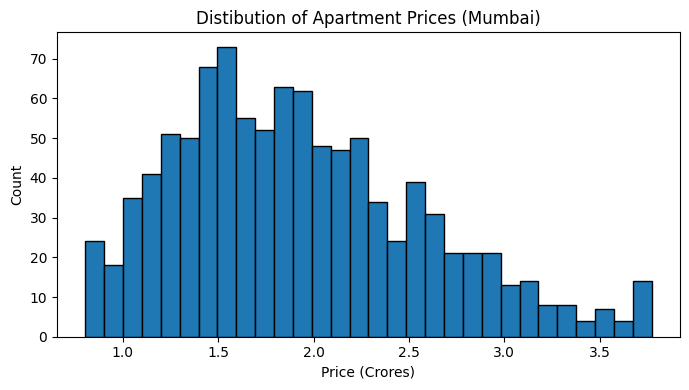

In [10]:
plt.figure(figsize=(7,4))
plt.hist(df["Price_INR"] / 1e7,bins=30,edgecolor="black")
plt.xlabel("Price (Crores)")
plt.ylabel("Count")
plt.title("Distibution of Apartment Prices (Mumbai)")
plt.tight_layout()
plt.show()

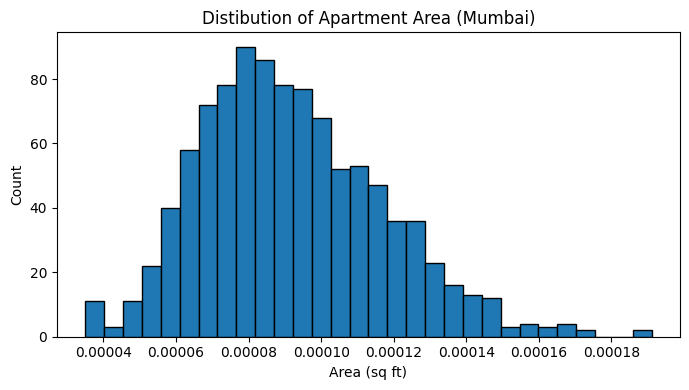

In [11]:
plt.figure(figsize=(7,4))
plt.hist(df["Area_sqft"] / 1e7,bins=30,edgecolor="black")
plt.xlabel("Area (sq ft)")
plt.ylabel("Count")
plt.title("Distibution of Apartment Area (Mumbai)")
plt.tight_layout()
plt.show()

C:\Users\Pratiksha\AppData\Local\Temp\ipykernel_24588\3851533024.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(prices_by_loc,labels=localities)


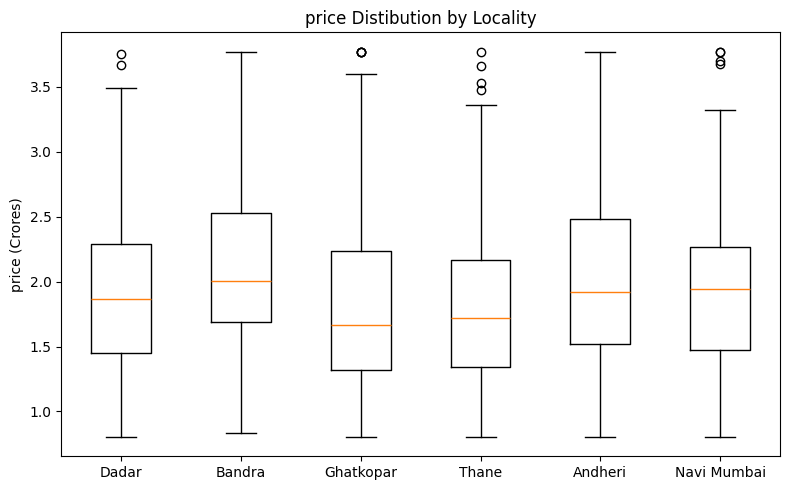

In [12]:
if "Locality" in df.columns:
    plt.figure(figsize=(8,5))
    localities = df["Locality"].unique().tolist()
    prices_by_loc=[df[df["Locality"]==loc]["Price_INR"] / 1e7 for loc in localities]
    plt.boxplot(prices_by_loc,labels=localities)
    plt.ylabel("price (Crores)")
    plt.title("price Distibution by Locality")
    plt.tight_layout()
    plt.show()

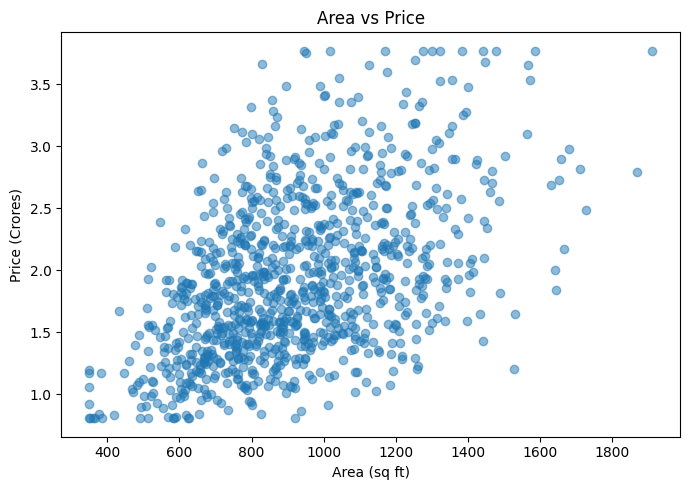

In [13]:
plt.figure(figsize=(7,5))
plt.scatter(df["Area_sqft"],df["Price_INR"]/ 1e7,alpha=0.5)
plt.xlabel("Area (sq ft)")
plt.ylabel("Price (Crores)")
plt.title("Area vs Price")
plt.tight_layout()
plt.show()

In [14]:
numeric_cols=["Area_sqft","BHK","Age_yrs","Floor","Total_Floors","Dist_Rail_km","Sea_View","Parking","Price_INR"]
numeric_cols=[c for c in numeric_cols if c in df.columns]    
corr=df[numeric_cols].corr()
print("\nCorrelational Matrix")
print(corr)


Correlational Matrix
              Area_sqft       BHK   Age_yrs     Floor  Total_Floors  \
Area_sqft      1.000000  0.567727  0.010324  0.020835     -0.016467   
BHK            0.567727  1.000000 -0.017572  0.005006     -0.006607   
Age_yrs        0.010324 -0.017572  1.000000 -0.004243     -0.026869   
Floor          0.020835  0.005006 -0.004243  1.000000      0.587861   
Total_Floors  -0.016467 -0.006607 -0.026869  0.587861      1.000000   
Dist_Rail_km  -0.019681  0.006231 -0.042458  0.005811     -0.030534   
Sea_View       0.005443  0.017800  0.027560  0.015494      0.023366   
Parking        0.013775 -0.004633 -0.043574 -0.071336     -0.029257   
Price_INR      0.486768  0.304613 -0.526793  0.307982      0.004917   

              Dist_Rail_km  Sea_View   Parking  Price_INR  
Area_sqft        -0.019681  0.005443  0.013775   0.486768  
BHK               0.006231  0.017800 -0.004633   0.304613  
Age_yrs          -0.042458  0.027560 -0.043574  -0.526793  
Floor             0.005811 

3. Minimal feature preparation
 

In [16]:
df["Price_Lakh"]=df["Price_INR"]

In [17]:
import pandas as pd
print(pd.__version__)

2.3.3


In [18]:
if "Locality" in df.columns:
    df_encoded=pd.get_dummies(df,columns=["Locality"],drop_first=True)
else:
    df_encoded=df.copy()

In [19]:
df=pd.read_csv("mumbai_housing_data.csv")
print("First 5 rows of raw data: \n")
print(df_encoded.head())

First 5 rows of raw data: 

   Area_sqft  BHK  Age_yrs  Floor  Total_Floors  Dist_Rail_km  Sea_View  \
0     583.22    1       10      8            15          2.74         0   
1     784.96    1       20      4             5          4.93         0   
2     793.64    3       14     19            19          3.12         1   
3     968.72    1       24     18            18          3.14         0   
4    1089.77    4       34     17            18          2.14         0   

   Parking   Price_INR  Price_Lakh  Locality_Bandra  Locality_Dadar  \
0        1  18045592.0  18045592.0            False            True   
1        0  23882179.0  23882179.0             True           False   
2        1  24259453.0  24259453.0            False           False   
3        0  18824996.0  18824996.0            False           False   
4        1  26278509.0  26278509.0            False           False   

   Locality_Ghatkopar  Locality_Navi Mumbai  Locality_Thane  
0               False           

4. Model Training

In [20]:
target = "Price_Lakh"
feature_cols=[col for col in df_encoded.columns if col not in["Price_INR",target]]

In [21]:
x=df_encoded[feature_cols]
y=df_encoded[target]
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [22]:
print(f"\nTraining samples: {x_train.shape[0]},Test samples :{x_test.shape[0]}")


Training samples: 800,Test samples :200


In [23]:
model=LinearRegression()
model.fit(x_train,y_train)
print("\n Model Traied: Linear Regression")


 Model Traied: Linear Regression


In [24]:
y_pred=model.predict(x_test)
mae=mean_absolute_error(y_test,y_pred)
rmse=np.sqrt(mean_squared_error(y_test,y_pred))
r2=r2_score(y_test,y_pred)

In [25]:
print("\nEVALUTION METRICS (Test Set:) ")
print(f"Mean Absoulte Error (MAE):{mae:2f} Lakh")
print(f"Root Mean Squared Error (RMSE):{rmse:.2f} Lakh")
print(f"R² Score: {r2:.4f}")


EVALUTION METRICS (Test Set:) 
Mean Absoulte Error (MAE):1365156.074356 Lakh
Root Mean Squared Error (RMSE):1711388.92 Lakh
R² Score: 0.9150


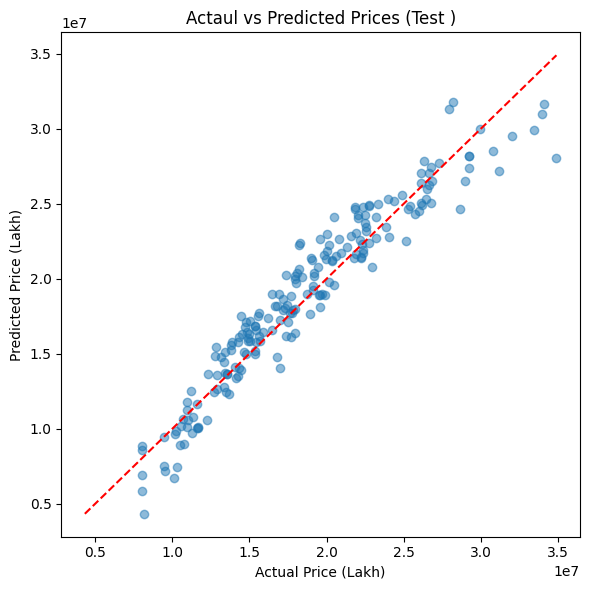

In [26]:
#Scatter plot :Actual vs Predicted
plt.figure(figsize=(6,6))
plt.scatter(y_test,y_pred,alpha=0.5)
plt.xlabel("Actual Price (Lakh)")
plt.ylabel("Predicted Price (Lakh)")
plt.title("Actaul vs Predicted Prices (Test )")
min_val=min(y_test.min(),y_pred.min())
max_val=max(y_test.max(),y_pred.max())
plt.plot([min_val,max_val],[min_val,max_val],"r--")
plt.tight_layout()
plt.show()

In [28]:
results=pd.DataFrame({
    "Actual_Lakh":y_test.values[:10],
    "Predicted_Lakh":y_pred[:10]
})
print("\nSample Prediction comparison(first 10 test rows:)\n")
print(results.round(2))


Sample Prediction comparison(first 10 test rows:)

   Actual_Lakh  Predicted_Lakh
0   9492276.00      9471599.83
1  12760414.00     14866100.89
2  10260650.00      9834506.15
3  20614335.00     21529558.78
4  15895250.00     16479714.15
5  19017245.00     21394976.65
6  31176260.00     27191397.83
7  11630444.00     11656425.15
8   8034724.05      5884384.90
9  21330608.00     22112963.86
